# 3. Student Outcomes, Bad-Case Review, and Guardrails

We first complete the evaluation story by visualizing student S1–S6 scores for the same six sessions. We then review failure cases and show how rule-based and LLM-based guardrails work together.

In [12]:
from pathlib import Path
import json,sys,pandas as pd
from IPython.display import display
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from display_utils import setup_notebook_display,paired_radar,flagged_dialogue_html,prompt_block
from evaluation_v2 import DialogueEvaluationV2,STUDENT_FIELDS
from early_stopping import decide_next_action,combine_guardrail_decisions,GUARDRAIL_LLM_PROMPT
setup_notebook_display()
records=[DialogueEvaluationV2.model_validate(x).model_dump() for x in json.loads((ROOT/'data/dialogue_evaluations_tutorial.json').read_text())]
scores=pd.DataFrame(records); student_labels=[f'S{i}' for i in range(1,7)]
guardrails=json.loads((ROOT/'data/guardrail_dialogues_tutorial.json').read_text())

(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Short session — student S1–S6'}>)

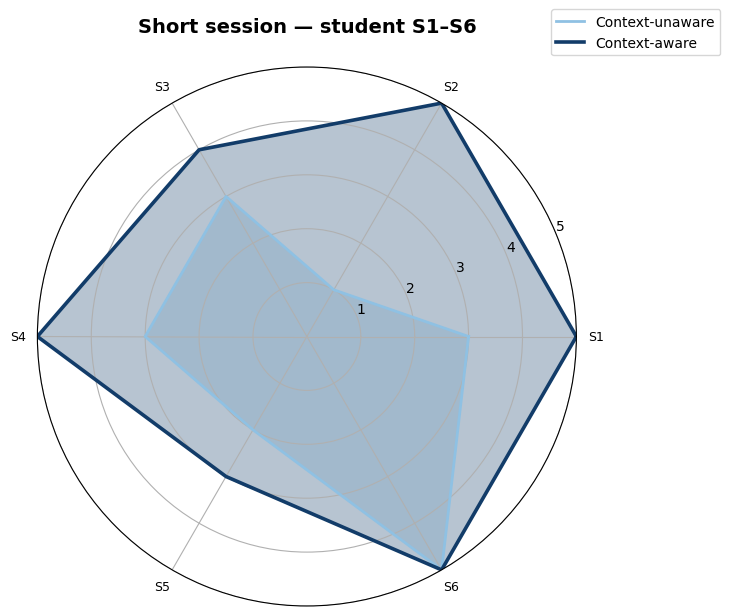

In [13]:
pair=scores[scores.pair_id=='short'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',STUDENT_FIELDS].tolist(),pair.loc['non_context_aware',STUDENT_FIELDS].tolist(),student_labels,'Short session — student S1–S6')

(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Medium session — student S1–S6'}>)

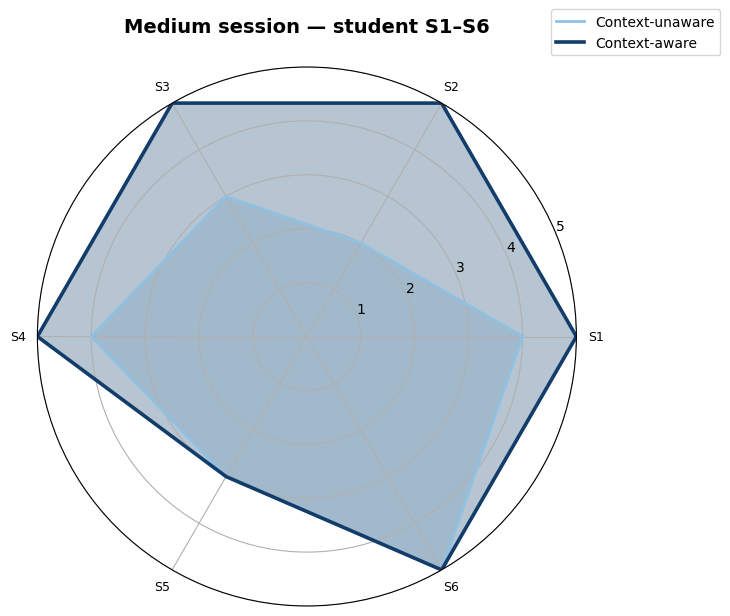

In [14]:
pair=scores[scores.pair_id=='medium'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',STUDENT_FIELDS].tolist(),pair.loc['non_context_aware',STUDENT_FIELDS].tolist(),student_labels,'Medium session — student S1–S6')

(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Long session — student S1–S6'}>)

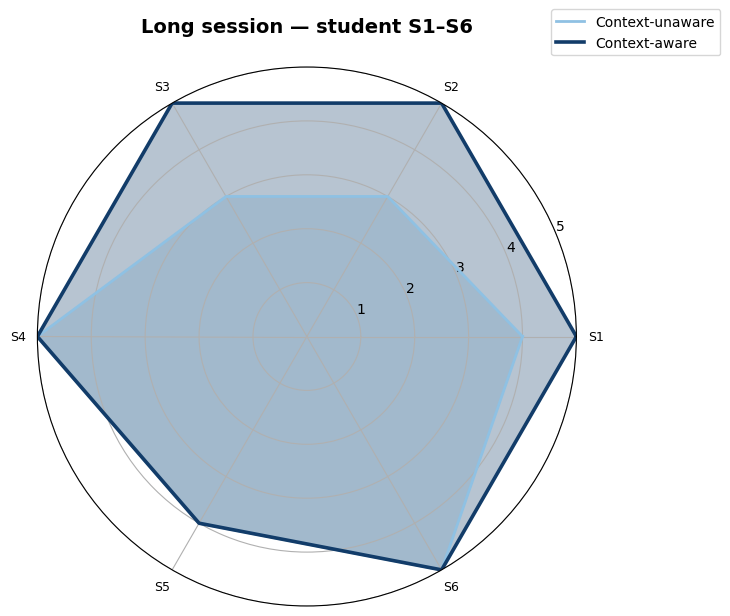

In [15]:
pair=scores[scores.pair_id=='long'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',STUDENT_FIELDS].tolist(),pair.loc['non_context_aware',STUDENT_FIELDS].tolist(),student_labels,'Long session — student S1–S6')

## Four bad-case patterns

Red highlights identify the risk signal or failure. Green highlights identify the recommended intervention strategy.

In [16]:
case=next(x for x in guardrails if x['case_id']=='g_stop_abuse')
case['messages'][0]['flags']=['Shut up','idiot']; case['messages'][1]['strategies']=['keep the conversation respectful','pause here']
display(flagged_dialogue_html(case))

In [17]:
case=next(x for x in guardrails if x['case_id']=='g_redirect_stalled')
case['messages'][0]['flags']=['still do not know']; case['messages'][1]['strategies']=['previous approach did not help','smaller question']
display(flagged_dialogue_html(case))

In [19]:
case=next(x for x in guardrails if x['case_id']=='g_hybrid_semantic')
case['messages'][0]['flags']=['not be a reason for me to be here tomorrow']; case['messages'][-1]['strategies']=['stricter confident decision','escalate']
display(flagged_dialogue_html(case))

In [20]:
case=next(x for x in guardrails if x['case_id']=='g_redirect_out_of_scope')
case['messages'][1]['flags']=['differentiate x squared using calculus']; case['messages'][2]['flags']=['Use the power rule']
case['messages'][3]['strategies']=['beyond our current objective','useful connection','explore derivatives with your teacher afterward']
display(flagged_dialogue_html(case))

## Hybrid decision logic

- Rules handle explicit high-risk phrases, hard product limits, and known state with low latency.
- The LLM detects paraphrases, indirect distress, intent, and semantic drift from recent context.
- Curriculum scope uses the student's grade, current objective, and curriculum evidence. An out-of-scope question is still learning-related: preserve curiosity, bridge to a prerequisite, and redirect instead of treating it as off-topic behavior.
- A high-confidence LLM result may raise intervention severity. It cannot weaken a stricter rule result.
- The final actions are `continue`, `verify_learning`, `support`, `redirect`, `stop`, or `escalate`.

In [22]:
prompt_block(GUARDRAIL_LLM_PROMPT,['Priority order','escalate','stop','support','verify_learning','redirect','continue','Return JSON only'])
output_contract={'action':'one of six actions','reason':'short evidence-based label','confidence':'0.0–1.0','response':'brief age-appropriate tutor response','terminal':'whether the session must end','severity':'0–3'}
display(pd.DataFrame([output_contract]).T.rename(columns={0:'LLM output field'}))

,LLM output field
action,one of six actions
reason,short evidence-based label
confidence,0.0–1.0
response,brief age-appropriate tutor response
terminal,whether the session must end
severity,0–3
